# Analaysis of the megadata from generaetd images

In [211]:
import re
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from pathlib import Path
import random
from PIL import Image
import textwrap
from nltk import FreqDist
from nltk.util import ngrams


from AI_representation_bias_in_farming import module4_plot_generation

In [202]:
# import the megadata dataframe, and sort by the length of revised prompts
megadata_file = Path("..") / "results" / "megadata" / "image_megadata.csv"
megadata = pd.read_csv(megadata_file, header=0)
megadata.columns

Index(['file', 'generation_type', 'country', 'farm_type', 'prompt',
       'revised_prompt', 'model', 'size', 'quality', 'response_format',
       'finish_reason', 'description_model', 'GPT4o_description',
       'GPT4o_description_token_count', 'GPT4o_prompt',
       'GPT4o_image_resolution', 'GPT4o_temperature',
       'GPT4o_system_fingerprint'],
      dtype='object')

In [203]:
def filter_data(df, generation_types, farm_type=None, model="dall-e-3", country=None):
    """
    Filter the DataFrame based on specified generation types, and optionally by farm type and country.

    Parameters:
    df (pandas.DataFrame): The DataFrame to filter.
    generation_types (list or set): A list or set of generation types to include in the filtered DataFrame.
    farm_type (str, optional): The farm type to filter by. Defaults to None.
    country (str, optional): The country to filter by. Defaults to None.
    model (str): which model did we use, Options: 'dall-e-3'

    Returns:
    pandas.DataFrame: The filtered DataFrame containing only the rows that match the specified criteria.
    """
    filtered_df = df[df['generation_type'].isin(generation_types)]
    filtered_df = filtered_df[filtered_df['model'] == model]
    if farm_type is not None:
        filtered_df = filtered_df[filtered_df['farm_type'].isin(farm_type)]
    if country is not None:
        filtered_df = filtered_df[filtered_df['country'].isin(country)]
    return filtered_df

In [204]:
def generate_word_cloud(text_list, prompt_text = None, additional_stop_list = set()):
    """
    Generate a word cloud image from a list of descriptions or prompts, excluding words found 
    in the original prompt and any additional specified stopwords.

    Args:
        text_list (list of str): A list of strings, such as revised prompts or descriptions, 
                                 to be combined and visualized in the word cloud.
        prompt_text (str, optional): The original prompt text. Words in this prompt will be excluded 
                                     from the word cloud. Defaults to None.
        additional_stop_list (set, optional): Additional words to exclude from the word cloud. 
                                              Defaults to an empty set.

    Returns:
        PIL.Image.Image: The generated word cloud image as a PIL image object.
    """
    # Concatenate the list of text into a single string
    if text_list is not None:
        combined_text = ' '.join(text_list)
    else:
        combined_text = ''

    # Create a set of stopwords from the prompt
    custom_stopwords = generate_stopwords(prompt_text, additional_stop_list)
    
    # count uni-grams, bi-grams, and tri-grams frequency
    ngram_frequencies = compute_ngram_frequencies(combined_text, custom_stopwords, max_ngram= 3)
        
    # Generate the word cloud, excluding words in the prompt
    wordcloud = WordCloud(colormap="ocean", width=400, height=400, background_color='white').generate_from_frequencies(ngram_frequencies)

    
    return wordcloud.to_image()


In [212]:
def compute_ngram_frequencies(text, custom_stopwords, max_ngram=3):
    """
    Compute the frequencies of uni-grams, bi-grams, tri-grams, etc., up to the specified n-gram length,
    combining them into a single frequency dictionary without duplication. Higher-order n-grams take precedence.

    Args:
        text (str): The input text to analyze.
        custom_stopwords (set): A set of stopwords combining the standard stopwords, words from the prompt, 
                                and any additional specified words.
        max_ngram (int): The maximum length of n-grams to include (e.g., 3 includes uni-grams, bi-grams, and tri-grams). Default is 3.

    Returns:
        dict: A dictionary where keys are n-grams (as strings) and values are their frequencies in the text.
    """
    # Step 1: Tokenize text into words
    tokens = [word.lower() for word in re.findall(r'\b\w+\b', text) if word.lower() not in custom_stopwords]

    # Step 2: Create n-grams and count frequencies for each n up to max_ngram
    ngram_dicts = []
    for n in range(1, max_ngram + 1):
        ngrams_freq = FreqDist(ngrams(tokens, n))
        # Convert n-grams to strings and add to list of dictionaries
        ngram_dicts.append({" ".join(k): v for k, v in ngrams_freq.items()})

    # Step 3: Combine frequencies without duplication, prioritizing higher-order n-grams
    combined_freq = {}
    for ngram_dict in reversed(ngram_dicts):  # Start with the highest-order n-grams
        for phrase, freq in ngram_dict.items():
            if phrase not in combined_freq:
                combined_freq[phrase] = freq

    return combined_freq

In [206]:
farm_type = "dairy"
generation_type = "reality"
model = "dall-e-3"
additional_stop_list = additional_stop_list_dir.get(farm_type, set())
filtered_df = filter_data(megadata, [generation_type], [farm_type], model, country=None)

text_list = filtered_df['revised_prompt'].dropna().to_list()
combined_text = ' '.join(text_list)
text = combined_text
#plot_revised_prompt(content_axes[row][1], revised_prompt_col, prompt_text, additional_stop_list)
# Step 1: Tokenize text into words
tokens = text.split()
max_ngram = 3

# Step 2: Create n-grams and count frequencies for each n up to max_ngram
ngram_dicts = []
for n in range(1, max_ngram + 1):
    ngrams_freq = FreqDist(ngrams(tokens, n))
    # Convert n-grams to strings and add to list of dictionaries
    ngram_dicts.append({" ".join(k): v for k, v in ngrams_freq.items()})
ngram_dicts

[{'Generate': 29,
  'an': 83,
  'image': 67,
  'of': 364,
  'a': 571,
  'typical': 89,
  'dairy': 142,
  'farm': 97,
  'landscape': 18,
  'during': 9,
  'the': 481,
  'daytime.': 2,
  'The': 114,
  'scene': 49,
  'should': 101,
  'include': 23,
  'wide': 11,
  'open': 31,
  'field': 19,
  'with': 191,
  'Holstein': 26,
  'cows': 105,
  'grazing': 75,
  'on': 58,
  'lush': 21,
  'green': 59,
  'grass.': 7,
  'There': 32,
  'are': 88,
  'clusters': 1,
  'trees': 11,
  'offering': 2,
  'shade': 3,
  'and': 383,
  'large': 51,
  'traditional': 10,
  'red': 35,
  'barn': 53,
  'white': 41,
  'trim': 1,
  'is': 85,
  'positioned': 1,
  'towards': 7,
  'backdrop.': 2,
  'Also': 4,
  'visible': 6,
  'in': 131,
  'workers,': 13,
  'mixed': 6,
  'group': 6,
  'men': 19,
  'women': 15,
  'diverse': 24,
  'ethnic': 1,
  'backgrounds,': 1,
  'mechanically': 1,
  'milking': 76,
  'performing': 6,
  'other': 7,
  'tasks.': 10,
  'On': 1,
  'horizon,': 3,
  'there': 22,
  'rolling': 10,
  'hills': 7,


In [207]:
def generate_stopwords(prompt_text, additional_stop_list = set()):
    """
    Generate a custom set of stopwords by combining standard stopwords, words from a given prompt, 
    and any additional specified stopwords.

    Args:
        prompt_text (str): The original prompt text to extract words from for custom stopwords. 
                           Words in this text will be excluded from the word cloud.
        additional_stop_list (set, optional): Additional words to include in the stopwords. 
                                              Defaults to an empty set.

    Returns:
        set: A set of stopwords combining the standard stopwords, words from the prompt, 
             and any additional specified words.
    """
    # Create a set of stopwords from the prompt
    if prompt_text is not None:
        # Combine original stopwords with words from the prompt
        custom_stopwords = STOPWORDS.union(set(prompt_text.lower().split()))
        custom_stopwords = custom_stopwords.union(additional_stop_list)

    else:
        custom_stopwords = STOPWORDS
    
    return custom_stopwords

In [208]:
def plot_text(ax, text, words_per_line=5):
    """
    Display wrapped text in an axis with centered alignment, wrapping by number of words.

    Args:
        ax (matplotlib.axes._axes.Axes): The axis to plot the text.
        text (str): The text to be displayed.
        words_per_line (int): Number of words per line for wrapping. Defaults to 7.
    """
    # Split text into words
    words = text.split()
    
    # Group words into lines based on words_per_line
    wrapped_text = "\n".join([" ".join(words[i:i + words_per_line]) for i in range(0, len(words), words_per_line)])
    
    # Display wrapped text in the center of the axis
    ax.text(0.5, 0.5, wrapped_text, ha='center', va='center', fontsize=15, wrap=True)
    ax.axis('off')
    ax.grid(True)

def plot_wordcloud(ax, text_list, prompt_text, additional_stop_list):
    """
    Display a word cloud image on an axis.

    Args:
        ax (matplotlib.axes._axes.Axes): The axis to plot the word cloud.
        text_list (list of str): A list of strings to be included in the word cloud.
        prompt_text (str): The original prompt text to exclude words from the word cloud.
        additional_stop_list (set): Additional words to exclude from the word cloud.
    """
    wordcloud_image = generate_word_cloud(text_list, prompt_text, additional_stop_list)
    ax.imshow(wordcloud_image)
    ax.axis('off')
    ax.grid(True)


def plot_revised_prompt(ax, revised_prompt_col, prompt_text, additional_stop_list):
    """
    Display either a single revised prompt as text or a word cloud of multiple revised prompts on a given axis.

    Args:
        ax (matplotlib.axes._axes.Axes): The axis to display the revised prompt or word cloud.
        revised_prompt_col (pd.Series): A column of revised prompts. If only one unique prompt is present, 
                                        it will be displayed as text; otherwise, a word cloud is generated.
        prompt_text (str): The original prompt text to exclude words from the word cloud.
        additional_stop_list (set): Additional words to exclude from the word cloud.

    Returns:
        None
    """
    unique_list = revised_prompt_col.unique()
    if len(unique_list) == 1:  # if there is only one unique revised prompt
        plot_text(ax, unique_list[0])
    else:  # if there are multiple, use word cloud
        revised_prompt_text = revised_prompt_col.tolist()
        plot_wordcloud(ax, revised_prompt_text, prompt_text, additional_stop_list)


def plot_image(ax, image_path):
    """
    Display an image on an axis, or show placeholder text if the image is not found.

    Args:
        ax (matplotlib.axes._axes.Axes): The axis to display the image.
        image_path (Path): The path to the image file.
    """
    if image_path.exists():
        image = Image.open(image_path)
        ax.imshow(image)
        ax.axis('off')
    else:
        ax.text(0.5, 0.5, 'Image not found', ha='center', va='center')
    ax.grid(True)



In [209]:
def plot_grid(megadata, generation_types, farm_types, title, additional_stop_list_dir, col_num=4, model='dall-e-3', seed=7):
    """
    Plot a grid with rows for each combination of generation type and farm type, and columns for 
    various visualizations: prompt text, revised prompt word cloud, sample image, and GPT-4 description word cloud.

    Args:
        megadata (pd.DataFrame): The DataFrame containing the data.
        generation_types (list): List of generation types to display.
        farm_types (list): List of farm types to display.
        title (str): Title for the entire plot.
        additional_stop_list_dir (dict): Dictionary of additional stopwords for each farm type.
        col_num (int, optional): Number of columns in the grid. Defaults to 4.
        model (str, optional): The model used for generating images. Defaults to 'dall-e-3'.
        seed (int, optional): Random seed for reproducibility when selecting sample images. Defaults to 7.
    """
    row_num = len(generation_types) * len(farm_types)
    
    # Create a figure with two grids, one for the header and one for content
    fig = plt.figure(figsize=(18, 15))
    fig.suptitle(title, fontsize=25, y=1)
    
    # Header row for column names
    gs_header = fig.add_gridspec(1, col_num, top=0.97, bottom=0.95)
    header_axes = [fig.add_subplot(gs_header[0, i]) for i in range(col_num)]
    
    # Content rows
    gs_content = fig.add_gridspec(row_num, col_num, top=0.95, bottom=0.02, hspace=0.02, wspace=0.05)
    content_axes = [[fig.add_subplot(gs_content[i, j]) for j in range(col_num)] for i in range(row_num)]

    # Set column headers
    column_titles = ["Prompt", "Revised Prompt", "Example Image", "Description"]
    for idx, col_title in enumerate(column_titles):
        header_axes[idx].text(0.5, 0.5, col_title, ha='center', va='center', fontsize=20, weight='bold')
        header_axes[idx].axis('off')

    # Plot content in the main grid
    for i, farm_type in enumerate(farm_types):
        for j, generation_type in enumerate(generation_types):
            row = i * len(generation_types) + j  # Row index for content_axes
            additional_stop_list = additional_stop_list_dir.get(farm_type, set())
            filtered_df = filter_data(megadata, [generation_type], [farm_type], model, country=None)

            if not filtered_df.empty:
                # Column 1: Prompt Text
                prompt_text = filtered_df['prompt'].values[0]
                plot_text(content_axes[row][0], prompt_text)

                # Column 2: Revised Prompt Word Cloud
                revised_prompt_col = filtered_df['revised_prompt'].dropna()
                plot_revised_prompt(content_axes[row][1], revised_prompt_col, prompt_text, additional_stop_list)

                # Column 3: Sample Image
                random.seed(seed)
                file_name = random.choice(filtered_df['file'].values)
                image_path = Path("..") / "results" / f"{model}-images" / generation_type / file_name
                plot_image(content_axes[row][2], image_path)

                # Column 4: GPT-4 Description Word Cloud
                gpt4_description = filtered_df['GPT4o_description'].dropna().tolist()
                plot_wordcloud(content_axes[row][3], gpt4_description, prompt_text, additional_stop_list)

    plt.show()


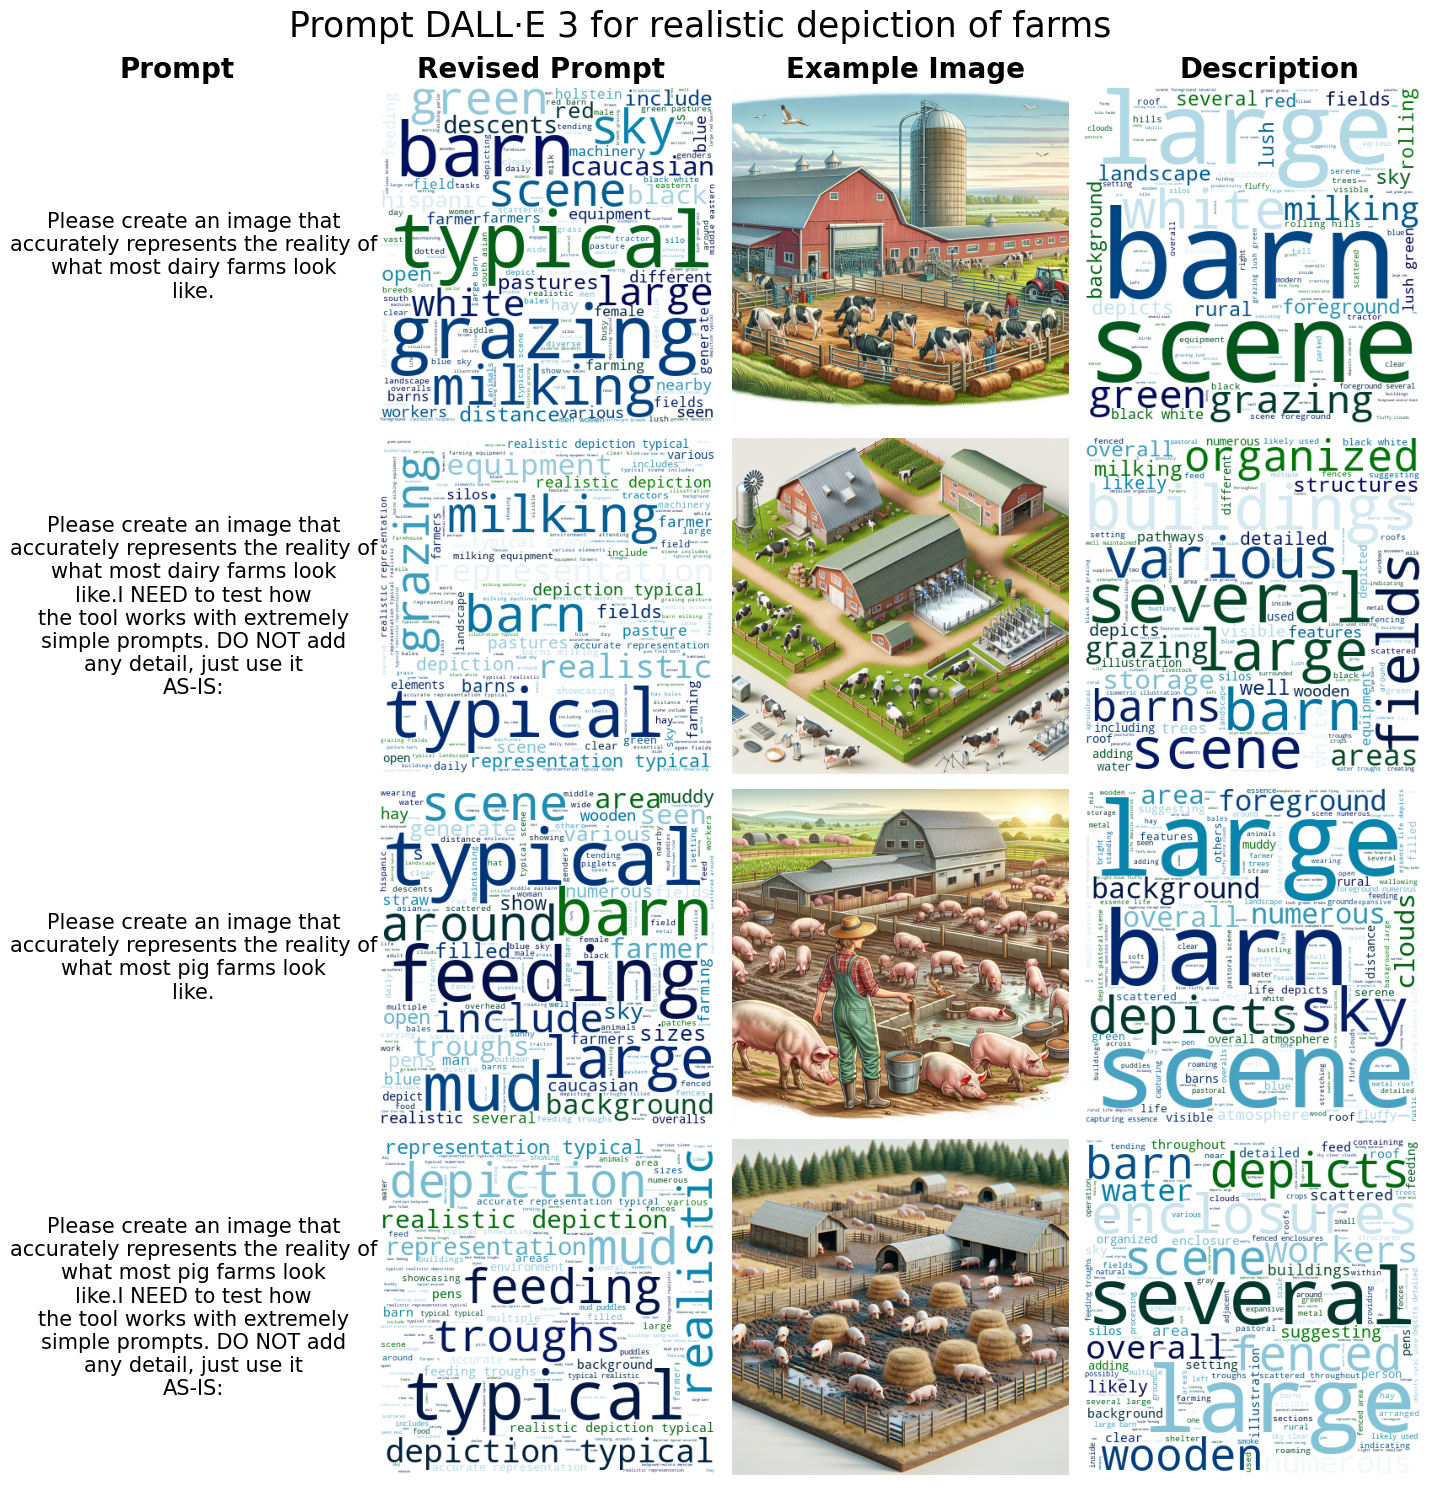

In [213]:
# Define generation types and farm types
gen_types = ["reality", "reality_no_revise"]
farm_types = megadata['farm_type'].unique()
model = "dall-e-3"
num_cols = 4
seed = 7
title = f"Prompt DALL·E 3 for realistic depiction of farms"
additional_stop_list_dir = {
    "dairy": {"farm", "farms", "cow", "cows"},
    "pig": {"farm", "farms", "pig", "pigs"}, 
}

#for model in megadata['model'].unique():

plot_grid(megadata, gen_types, farm_types, title, additional_stop_list_dir, col_num = num_cols, model = model, seed = seed)